# Model A – Model Training & Selection (Structural Features)

**Goal:** Train multiple classifiers on the hand‑crafted structural features
and pick the best one based on F1 score.

**Input:** `data/model_a/features.csv` – 12 numeric features + label.

**Plan:**
- Split into **train / val / test** (60/20/20, stratified) and save the splits.
- Train three lightweight models on the training set:
  - Random Forest
  - Logistic Regression
  - Naive Bayes
- Evaluate on the validation set.
- Final comparison on the test set with confusion matrix plots.
- Save the best model as `models/best_model_a.joblib`.

## 1) Load and Split the Data
We load the extracted features from `features.csv` and partition
them into **train (60%)**, **validation (20%)**, and **test (20%)**.

Stratification ensures each set maintains the same proportion of
phishing/legitimate emails as the original dataset — critical for
imbalanced data.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent   # adjust if needed
features_path = PROJECT_ROOT / "data" / "model_a" / "extracted_features" / "features.csv"
df = pd.read_csv(features_path)

X = df.drop(columns=["label"]).values
y = df["label"].values

print(f"Loaded {X.shape[0]} samples, {X.shape[1]} features")
print(f"Label distribution:\n{pd.Series(y).value_counts().sort_index()}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Loaded 164467 samples, 12 features
Label distribution:
0    78821
1    85646
Name: count, dtype: int64

Train: 98680 samples
Val:   32893 samples
Test:  32894 samples


The following code cell will `save splits to disk` to use them for several models. To ensure fairness between models.

In [3]:
splits_dir = PROJECT_ROOT / "data" / "model_a" / "splits"
splits_dir.mkdir(parents=True, exist_ok=True)

for name, (X_, y_) in zip(
    ["train", "val", "test"],
    [(X_train, y_train), (X_val, y_val), (X_test, y_test)]
):
    df_out = pd.DataFrame(X_, columns=df.drop(columns=["label"]).columns)
    df_out["label"] = y_
    df_out.to_csv(splits_dir / f"{name}.csv", index=False)
    print(f"Saved {name}.csv")

Saved train.csv
Saved val.csv
Saved test.csv


## 2) Models Training and Evaluation
We will train `3 models` and evaluate each one by using the `evaluation set` to decide whether we move to the next model or changing the parmeters of the model then train again.
### 2.1. Model 1 – Random Forest
A Random Forest classifier is an ensemble of decision trees that often
works well with dense numerical features like averaged word embeddings.

We’ll train on the **training set**, evaluate on the **validation set**,
and report:
- F1 score (main metric for this project)
- Precision & Recall
- Confusion matrix

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)

f1 = f1_score(y_val, y_val_pred)
print(f"Random Forest – Validation F1: {f1:.4f}")
print(classification_report(y_val, y_val_pred, target_names=["Legitimate", "Phishing"]))

Random Forest – Validation F1: 0.8242
              precision    recall  f1-score   support

  Legitimate       0.81      0.82      0.81     15764
    Phishing       0.83      0.82      0.82     17129

    accuracy                           0.82     32893
   macro avg       0.82      0.82      0.82     32893
weighted avg       0.82      0.82      0.82     32893



### 2.2. Model 2 – Logistic Regression
Logistic Regression is a linear model that works well with averaged word
embeddings. It serves as a quick, interpretable baseline.

We use the same training/validation split and report the same metrics.

In [5]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_val_pred = lr.predict(X_val)
f1 = f1_score(y_val, y_val_pred)
print(f"Logistic Regression – Validation F1: {f1:.4f}")
print(classification_report(y_val, y_val_pred, target_names=["Legitimate", "Phishing"]))

Logistic Regression – Validation F1: 0.7532
              precision    recall  f1-score   support

  Legitimate       0.78      0.54      0.64     15764
    Phishing       0.67      0.86      0.75     17129

    accuracy                           0.71     32893
   macro avg       0.73      0.70      0.70     32893
weighted avg       0.72      0.71      0.70     32893



c:\Users\zakar\anaconda3\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 2.3. Model 3 – Gaussian Naive Bayes (fast & simple)
It assumes features are normally distributed – a reasonable approximation
for averaged word vectors – and it trains almost instantly.

In [6]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_val_pred = nb.predict(X_val)
f1 = f1_score(y_val, y_val_pred)
print(f"Naive Bayes – Validation F1: {f1:.4f}")
print(classification_report(y_val, y_val_pred, target_names=["Legitimate", "Phishing"]))

Naive Bayes – Validation F1: 0.3753
              precision    recall  f1-score   support

  Legitimate       0.52      0.86      0.65     15764
    Phishing       0.67      0.26      0.38     17129

    accuracy                           0.55     32893
   macro avg       0.59      0.56      0.51     32893
weighted avg       0.60      0.55      0.50     32893



## 3) Model Selection

We now use the **test set** (unseen during training & validation) to measure
true generalization performance. For each model we:

- Predict labels on `X_test`
- Compute F1, precision, recall
- Plot a confusion matrix

So, The Final Evaluation will be on the Test Set.

Finally, we pick the best model according to **F1 score** and announce it.

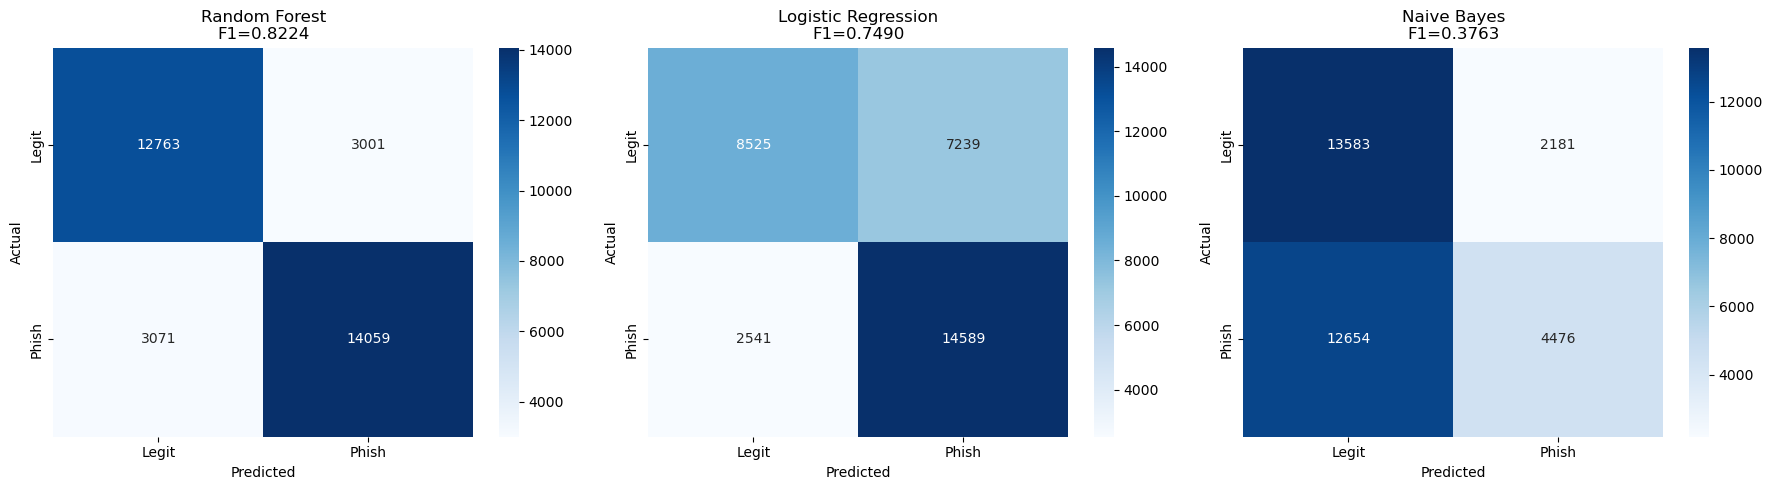


Test Set Performance Summary:
                         F1  Precision  Recall
Random Forest        0.8224     0.8241  0.8207
Logistic Regression  0.7490     0.6684  0.8517
Naive Bayes          0.3763     0.6724  0.2613

Best model based on F1 score: **Random Forest** (F1 = 0.8224)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

models = {
    "Random Forest": rf,
    "Logistic Regression": lr,
    "Naive Bayes": nb,
}

results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {"F1": f1, "Precision": prec, "Recall": rec}
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Legit", "Phish"],
                yticklabels=["Legit", "Phish"],
                ax=axes[i])
    axes[i].set_title(f"{name}\nF1={f1:.4f}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Print summary table
print("\nTest Set Performance Summary:")
summary_df = pd.DataFrame(results).T
print(summary_df.round(4))

# Determine the best model
best_model = max(results, key=lambda x: results[x]["F1"])
print(f"\nBest model based on F1 score: **{best_model}** (F1 = {results[best_model]['F1']:.4f})")

## 4) Save the Best Model
We save the winner (`best_model`) into the `models/` folder as
`best_model_b.joblib`. This file can be loaded directly in a deployment
notebook with `joblib.load()`.

In [8]:
import joblib
from pathlib import Path

models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

best_model_path = models_dir / "best_model_a.joblib"
joblib.dump(models[best_model], best_model_path)

print(f"Best model ('{best_model}') saved to: {best_model_path}")

Best model ('Random Forest') saved to: C:\Work\current\phishing_detection\models\best_model_a.joblib
